# Visualize exon-content manipulations

Compare the original test sequence against the four manipulations:

| Mode | What changes |
|---|---|
| `nt_shuffle` | Concatenate exons → permute every nt → write back |
| `codon_shuffle` | Concatenate exons → permute codons (frame 0) → write back |
| `remove1` | Delete one random nt from each exon (junctions shift) |
| `remove2` | Delete two random nt from each exon (junctions shift) |

**About UTRs:** the SpliceAI test datafile only stores transcript boundaries (`TX_START`/`TX_END`) and splice junctions (`JN_START`/`JN_END`). It does *not* store CDS boundaries, so 5′/3′ UTRs cannot be drawn from the datafile alone. Where the gene structure plot below would normally distinguish UTRs from coding exons, we instead colour by exon index. If you have CDS coordinates from a GFF (e.g. GENCODE), pass them to `plot_gene_structure(..., cds_span=(genomic_start, genomic_end))` and the function will shade the UTR portions of terminal exons in a paler tone.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import h5py
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
from manipulate_exons import build_exon_spans, gene_to_sense, get_gene_record

MODES = ['original', 'nt_shuffle', 'codon_shuffle', 'remove1', 'remove2']
DATAFILES = {
    'original':       REPO_ROOT / 'datafile_test_0.h5',
    'nt_shuffle':     REPO_ROOT / 'datafile_test_nt_shuffle.h5',
    'codon_shuffle':  REPO_ROOT / 'datafile_test_codon_shuffle.h5',
    'remove1':        REPO_ROOT / 'datafile_test_remove1.h5',
    'remove2':        REPO_ROOT / 'datafile_test_remove2.h5',
}
MANIFESTS = {
    m: REPO_ROOT / f'datafile_test_{m}.h5.manifest.json'
    for m in ['nt_shuffle', 'codon_shuffle', 'remove1', 'remove2']
}

for m, p in DATAFILES.items():
    print(f'{m:14s} {p.name:36s} {"OK" if p.exists() else "MISSING"}')

original       datafile_test_0.h5                   OK
nt_shuffle     datafile_test_nt_shuffle.h5          OK
codon_shuffle  datafile_test_codon_shuffle.h5       OK
remove1        datafile_test_remove1.h5             OK
remove2        datafile_test_remove2.h5             OK


## Pick a gene to visualize

We default to a moderately small multi-exon gene so the structure is legible. Change `GENE_NAME` to inspect anything else in the test set.

In [2]:
GENE_NAME = 'AZIN2'  # +-strand, 11 introns / 12 exons, gene_len ≈ 39kb

def find_gene_index(datafile_path: Path, name: str) -> int:
    with h5py.File(datafile_path, 'r') as f:
        for i, n in enumerate(f['NAME'][:]):
            if n.decode() == name:
                return i
    raise KeyError(f'Gene {name!r} not found in {datafile_path}')

GENE_IDX = find_gene_index(DATAFILES['original'], GENE_NAME)
print(f'{GENE_NAME} is at index {GENE_IDX}')

AZIN2 is at index 0


In [3]:
def load_record(mode: str, gene_idx: int) -> dict:
    with h5py.File(DATAFILES[mode], 'r') as f:
        rec = get_gene_record(f, gene_idx)
    sense, donors, acceptors = gene_to_sense(rec)
    gene_end_excl = rec['gene_offset'] + rec['gene_len']
    exons = build_exon_spans(donors, acceptors, rec['gene_offset'], gene_end_excl)
    rec['sense'] = sense
    rec['donors'] = donors
    rec['acceptors'] = acceptors
    rec['exons'] = exons
    rec['gene_end_excl'] = gene_end_excl
    return rec

records = {m: load_record(m, GENE_IDX) for m in MODES}
for m, r in records.items():
    print(f'{m:14s} strand={r["strand"]} gene_len={r["gene_len"]:6d} '
          f'exons={len(r["exons"]):3d}  donors={r["donors"][:2]}…  acceptors={r["acceptors"][:2]}…')

original       strand=+ gene_len= 39281 exons= 12  donors=[181, 395]…  acceptors=[275, 488]…
nt_shuffle     strand=+ gene_len= 39281 exons= 12  donors=[181, 395]…  acceptors=[275, 488]…
codon_shuffle  strand=+ gene_len= 39281 exons= 12  donors=[181, 395]…  acceptors=[275, 488]…
remove1        strand=+ gene_len= 39269 exons= 12  donors=[180, 393]…  acceptors=[274, 486]…
remove2        strand=+ gene_len= 39257 exons= 12  donors=[179, 391]…  acceptors=[273, 484]…


## Gene-structure track plot

Each row is one of the five sequence states. Boxes are exons (coloured by index so you can follow the same exon across rows). Thin grey lines between boxes are introns. Vertical ticks above the track mark the splice sites (`▲` donor at exon end, `▼` acceptor at exon start). The dashed grey line shows TX_START..TX_END so you can see length changes from the deletion modes.

If you pass `cds_span=(g_start, g_end)` (genomic coordinates), the portion of terminal exons outside that span is shaded paler to indicate UTR.

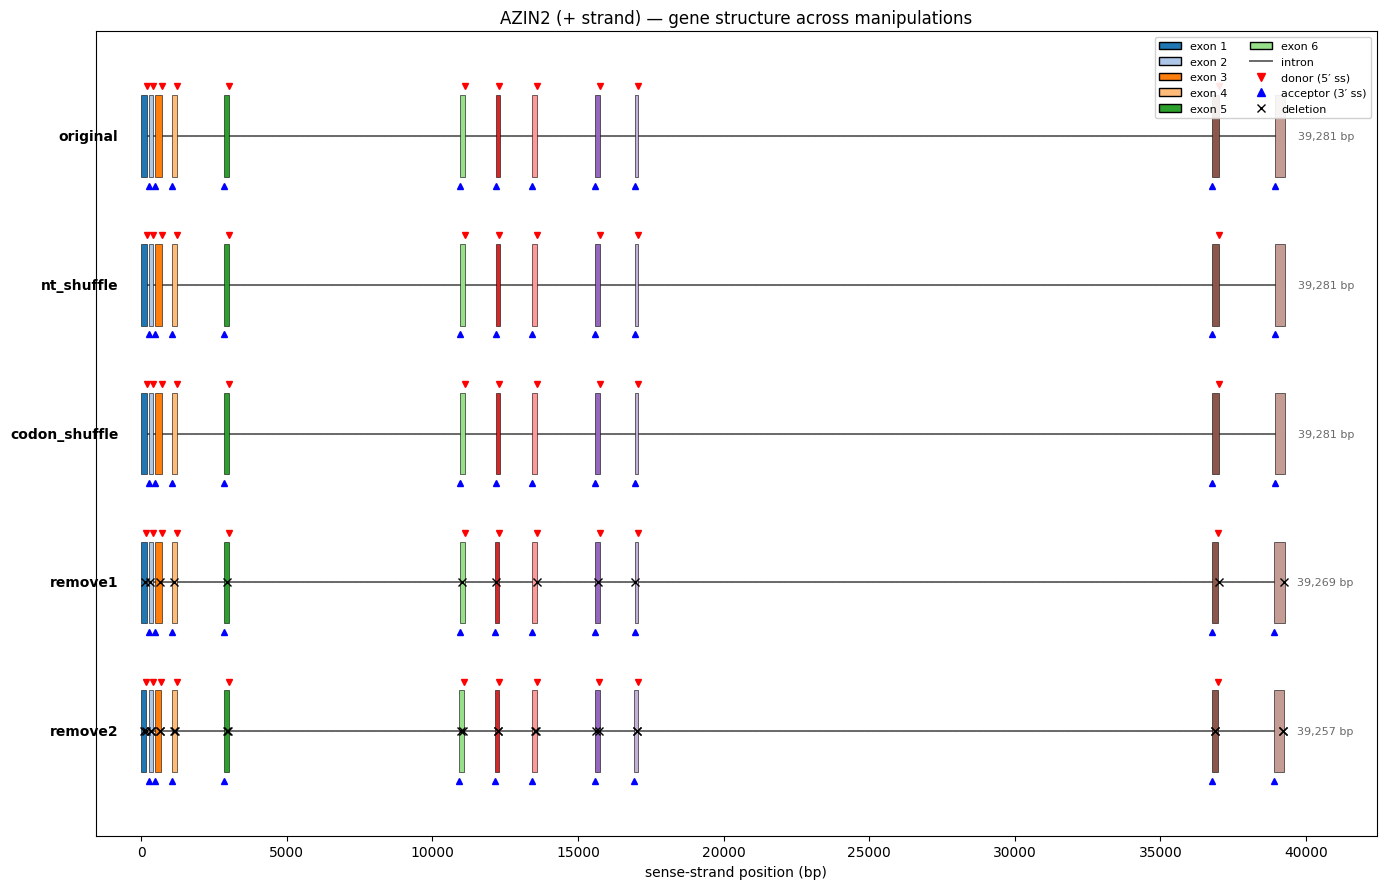

In [4]:
def genomic_to_sense(rec: dict, g: int) -> int:
    if rec['strand'] == '+':
        return g - rec['tx_start']
    return rec['tx_end'] - g

def plot_gene_structure(records: dict, cds_span: tuple | None = None,
                         deletions_by_mode: dict | None = None,
                         figsize=(14, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap('tab20')
    n_modes = len(records)
    row_height = 1.0
    box_h = 0.55

    max_len = max(r['gene_len'] for r in records.values())

    for ri, (mode, rec) in enumerate(records.items()):
        y = (n_modes - 1 - ri) * row_height
        offset = rec['gene_offset']
        # Backbone (TX span)
        ax.plot([0, rec['gene_len']], [y, y], color='lightgrey', lw=0.8, ls='--', zorder=1)
        # Intron strokes between exons
        exons = rec['exons']
        for (s1, e1), (s2, e2) in zip(exons[:-1], exons[1:]):
            ax.plot([e1 - offset, s2 - offset], [y, y], color='dimgrey', lw=1.4, zorder=2)
        # Exon boxes (colour by exon index)
        for ei, (s, e) in enumerate(exons):
            colour = cmap(ei % 20)
            x = s - offset
            w = e - s
            ax.add_patch(mpatches.Rectangle((x, y - box_h / 2), w, box_h,
                                            facecolor=colour, edgecolor='black', lw=0.4, zorder=3))
        # CDS-derived UTR shading (terminal exons only) if cds_span provided
        if cds_span is not None:
            cds_s_sense = genomic_to_sense(rec, cds_span[0])
            cds_e_sense = genomic_to_sense(rec, cds_span[1])
            cds_lo, cds_hi = sorted((cds_s_sense, cds_e_sense))
            for s, e in exons:
                # Shade portion that lies outside CDS (= UTR) with a translucent overlay
                if e <= cds_lo or s >= cds_hi:
                    x0, x1 = s - offset, e - offset
                else:
                    if s < cds_lo:
                        x0, x1 = s - offset, cds_lo - offset
                        ax.add_patch(mpatches.Rectangle((x0, y - box_h / 2), x1 - x0, box_h,
                                                        facecolor='white', alpha=0.55,
                                                        edgecolor='none', zorder=4))
                    if e > cds_hi:
                        x0, x1 = cds_hi - offset, e - offset
                        ax.add_patch(mpatches.Rectangle((x0, y - box_h / 2), x1 - x0, box_h,
                                                        facecolor='white', alpha=0.55,
                                                        edgecolor='none', zorder=4))
                    continue
                ax.add_patch(mpatches.Rectangle((x0, y - box_h / 2), x1 - x0, box_h,
                                                facecolor='white', alpha=0.55,
                                                edgecolor='none', zorder=4))
        # Splice site markers
        for d in rec['donors']:
            ax.plot(d - offset, y + box_h / 2 + 0.06, marker='v', markersize=5,
                    color='red', zorder=5)
        for a in rec['acceptors']:
            ax.plot(a - offset, y - box_h / 2 - 0.06, marker='^', markersize=5,
                    color='blue', zorder=5)
        # Deletion ticks (for remove1 / remove2)
        if deletions_by_mode and mode in deletions_by_mode:
            for pos in deletions_by_mode[mode]:
                ax.plot(pos, y, marker='x', markersize=6, color='black', zorder=6)
        # Row label
        ax.text(-max_len * 0.02, y, mode, ha='right', va='center', fontsize=10, fontweight='bold')
        # Length annotation
        ax.text(rec['gene_len'] + max_len * 0.005, y, f"  {rec['gene_len']:,} bp",
                ha='left', va='center', fontsize=8, color='dimgrey')

    ax.set_xlim(-max_len * 0.04, max_len * 1.08)
    ax.set_ylim(-0.7, n_modes * row_height - 0.3)
    ax.set_yticks([])
    ax.set_xlabel('sense-strand position (bp)')
    title = f'{records["original"]["name"]} ({records["original"]["strand"]} strand) — gene structure across manipulations'
    ax.set_title(title)

    legend_handles = [
        mpatches.Patch(facecolor=cmap(i % 20), edgecolor='black', label=f'exon {i+1}')
        for i in range(min(len(records['original']['exons']), 6))
    ]
    legend_handles += [
        plt.Line2D([], [], color='dimgrey', lw=1.4, label='intron'),
        plt.Line2D([], [], marker='v', color='red', lw=0, label='donor (5′ ss)'),
        plt.Line2D([], [], marker='^', color='blue', lw=0, label='acceptor (3′ ss)'),
        plt.Line2D([], [], marker='x', color='black', lw=0, label='deletion'),
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    plt.tight_layout()
    return fig

# Build deletion position lookups from manifests
deletions_by_mode = {}
for mode in ('remove1', 'remove2'):
    with open(MANIFESTS[mode]) as fp:
        m = json.load(fp)
    g = m['genes'][GENE_IDX]
    deletions_by_mode[mode] = [d['abs_pos'] - records[mode]['gene_offset'] for d in g['deletions']]

fig = plot_gene_structure(records, cds_span=None, deletions_by_mode=deletions_by_mode)
plt.show()

## Optional: overlay UTRs

If you know the CDS span (start codon → stop codon, in *genomic* coordinates), set `CDS_SPAN` and re-plot. Terminal-exon regions outside the CDS will shade paler to mark UTRs. For AZIN2 (RefSeq NM_052998 on chr1, +): CDS ≈ 33,547,029–33,585,750. Replace with your own gene's CDS as appropriate, or leave as `None` to omit.

In [5]:
CDS_SPAN = None  # e.g. (33547029, 33585750) for AZIN2 — replace with your CDS
if CDS_SPAN is not None:
    fig = plot_gene_structure(records, cds_span=CDS_SPAN, deletions_by_mode=deletions_by_mode)
    plt.show()
else:
    print('CDS_SPAN is None — UTR overlay skipped. Set CDS_SPAN above to enable.')

CDS_SPAN is None — UTR overlay skipped. Set CDS_SPAN above to enable.


## Zoom: per-exon sequence content

Pick one exon and show its actual nucleotide sequence across all five states, side by side. This makes it visually obvious that:

* `nt_shuffle` permutes individual letters,
* `codon_shuffle` permutes 3-letter blocks (composition by codon is preserved),
* `remove1` / `remove2` produce a 1- or 2-character-shorter exon.

In [6]:
def render_exon_text(records: dict, exon_idx: int, max_chars: int = 120) -> None:
    print(f'Exon {exon_idx + 1} of {records["original"]["name"]} (showing up to first {max_chars} chars):\n')
    for mode, rec in records.items():
        exons = rec['exons']
        if exon_idx >= len(exons):
            print(f'  {mode:14s} <exon {exon_idx + 1} does not exist after manipulation>')
            continue
        s, e = exons[exon_idx]
        seq = rec['sense'][s:e]
        truncated = seq[:max_chars] + ('…' if len(seq) > max_chars else '')
        print(f'  {mode:14s} len={len(seq):4d}  {truncated}')
    print()

for ei in (0, 1, len(records['original']['exons']) - 1):
    render_exon_text(records, ei, max_chars=90)

Exon 1 of AZIN2 (showing up to first 90 chars):

  original       len= 182  TGGGCGGGGTTATATAAGCCAGCGGCGGGCGGAAGGCGGGGCGTGGGGGTCTGTGGCTGCTGGGCTGGCGGGGCGCAGGCCGCGGGACCC…
  nt_shuffle     len= 182  CCTCAAGCTACGCTTGGCTGGGGTGCAACCAAGGCCCTATCCTTTGTAGGAACACTGAGGGGCCGAGTCACGCCACGCACCCGCAGCCTA…
  codon_shuffle  len= 182  CCTACATGGACCCGGCACCTGCCCAGCCCTGCAACTCCAAGGCATTACTTGAGTAATAAGGCCTGGTTGTGCTGGTGCGGCTAACTGACC…
  remove1        len= 181  TGGGCGGGGTTATATAAGCCAGCGGCGGGCGGAAGGCGGGGCGTGGGGGTCTGTGGCTGCTGGGCTGGCGGGGCGCAGGCCGCGGGACCC…
  remove2        len= 180  TGGGCGGGGTTATATAAGCCAGCGGCGGGCGGAAGGCGGGGCGTGGGGGTCTGTGGCTGCTGGGCTGGCGGGGCGCAGGCCGCGGGACCC…

Exon 2 of AZIN2 (showing up to first 90 chars):

  original       len= 121  CAGAGGCCTCGGCTCCGCAACTGCCACTCCTCCTCGGGGTGTTGCACAAGTTTCGAGGTCACCGGCGACCCCCCCTAGCAGCGCGCCTGG…
  nt_shuffle     len= 121  GACTCCCCATATGCTTGTCATCACGTTCCTGAATAAGAATTCGGAATCTGAAGGTCCGCAGGGTCCCGCCGTGAGATACCTTGTGAGATC…
  codon_shuffle  len= 121  CCAGAGCAGATGGTTGTGGACTTCCATCTCGTCAGAAAGTG

## Composition check (shuffle modes)

Both shuffle modes preserve nucleotide composition exactly. `codon_shuffle` additionally preserves codon composition (we count 3-letter words on the concatenated exonic sequence).

In [7]:
from collections import Counter

def concat_exonic(rec: dict) -> str:
    return ''.join(rec['sense'][s:e] for s, e in rec['exons'])

def codon_counts(seq: str) -> Counter:
    n = (len(seq) // 3) * 3
    return Counter(seq[i:i+3] for i in range(0, n, 3))

orig_concat = concat_exonic(records['original'])
print(f'Original exonic concat length: {len(orig_concat)} bp')
print(f'Nucleotide composition (orig): {dict(Counter(orig_concat))}')

for mode in ('nt_shuffle', 'codon_shuffle'):
    cur = concat_exonic(records[mode])
    nt_match = Counter(cur) == Counter(orig_concat)
    codon_match = codon_counts(cur) == codon_counts(orig_concat)
    print(f'  {mode:14s} length={len(cur)}  nt-composition preserved: {nt_match}  codon-composition preserved: {codon_match}')

Original exonic concat length: 2181 bp
Nucleotide composition (orig): {'T': 452, 'G': 681, 'C': 615, 'A': 433}
  nt_shuffle     length=2181  nt-composition preserved: True  codon-composition preserved: False
  codon_shuffle  length=2181  nt-composition preserved: True  codon-composition preserved: True


## Where are the deletions?

For `remove1` / `remove2`, plot the fractional position of each deletion within its host exon. If the model relies on positional content within an exon (e.g. terminal exonic enhancers), the per-deletion AUPRC drop should correlate with this fractional position.

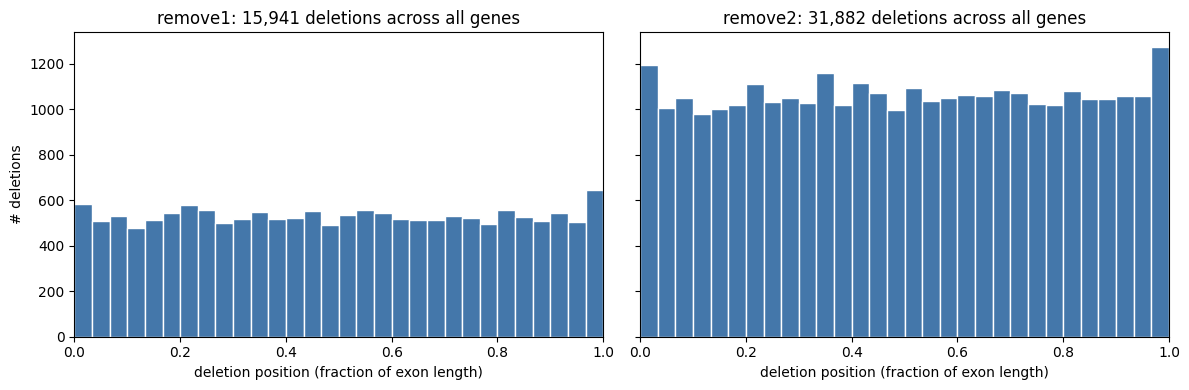

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, mode in zip(axes, ('remove1', 'remove2')):
    with open(MANIFESTS[mode]) as fp:
        m = json.load(fp)
    fracs = [d['frac_in_exon'] for g in m['genes'] for d in g['deletions']]
    ax.hist(fracs, bins=30, color='#4477aa', edgecolor='white')
    ax.set_xlabel('deletion position (fraction of exon length)')
    ax.set_title(f'{mode}: {len(fracs):,} deletions across all genes')
    ax.set_xlim(0, 1)
axes[0].set_ylabel('# deletions')
plt.tight_layout()
plt.show()

## Sanity — splice-site dinucleotides survive every manipulation

All four manipulations only touch *exonic* nucleotides; intron content (including the canonical `GT…AG` motifs) is untouched. We re-check at the chosen gene's junctions to confirm the model still sees a valid splice site context after manipulation.

In [9]:
for mode, rec in records.items():
    rows = []
    for d in rec['donors']:
        if d + 3 <= len(rec['sense']):
            rows.append(('donor', d, rec['sense'][d-2:d+1], rec['sense'][d+1:d+3]))
    for a in rec['acceptors']:
        if a >= 2:
            rows.append(('acceptor', a, rec['sense'][a-2:a], rec['sense'][a:a+3]))
    rows.sort(key=lambda r: r[1])
    print(f'\n=== {mode} ===  exonic context | intronic motif')
    for kind, p, ex_ctx, intr in rows[:8]:
        print(f'  {kind:8s} pos {p:6d}   exonic …{ex_ctx}|  intronic |{intr}…')


=== original ===  exonic context | intronic motif
  donor    pos    181   exonic …AAG|  intronic |GC…
  acceptor pos    275   exonic …AG|  intronic |CAG…
  donor    pos    395   exonic …TTG|  intronic |GT…
  acceptor pos    488   exonic …AG|  intronic |GAG…
  donor    pos    699   exonic …TAG|  intronic |GT…
  acceptor pos   1065   exonic …AG|  intronic |TGT…
  donor    pos   1241   exonic …ACG|  intronic |GT…
  acceptor pos   2841   exonic …AG|  intronic |GAC…

=== nt_shuffle ===  exonic context | intronic motif
  donor    pos    181   exonic …GGC|  intronic |GC…
  acceptor pos    275   exonic …AG|  intronic |GAC…
  donor    pos    395   exonic …GAC|  intronic |GT…
  acceptor pos    488   exonic …AG|  intronic |GCT…
  donor    pos    699   exonic …CAT|  intronic |GT…
  acceptor pos   1065   exonic …AG|  intronic |CAA…
  donor    pos   1241   exonic …CGC|  intronic |GT…
  acceptor pos   2841   exonic …AG|  intronic |TAT…

=== codon_shuffle ===  exonic context | intronic motif
  donor 